# Introduction

From the beginning of the COVID-19 pandemic in the US, early mortality rates reflected long-standing systemic inequities.

The goal of this analysis is to investigate the relationship between county-level socioeconomic factors and early COVID-19 mortality rates, with particular attention to the most vulnerable population: individuals aged 60 and older. COVID time-series and American Community Survey (ACS) data were combined to answer the question: "During the initial wave, which socioeconomic factors best predict the pandemic's severity?"

# Data Loading & Cleaning

In [1]:
# Imports & Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# Data loading

# COVID deaths time series
covid_df = pd.read_csv('/kaggle/input/datasets/jieyingwu/covid19-us-countylevel-summaries/deaths_timeseries.csv')

# ACS demographics
acs_df = pd.read_csv('/kaggle/input/datasets/jtourkis/us-county-level-acs-features-for-covid-analysis/ACS_full_data_w_over_60_3.csv')

print(f"COVID Data Shape: {covid_df.shape}")
print(f"ACS Data Shape: {acs_df.shape}")

display(covid_df.head(2))
display(acs_df.head(2))

COVID Data Shape: (3142, 69)
ACS Data Shape: (1476, 89)


,FIPS,Combined_Key,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,...,3/19/20,3/20/20,3/21/20,3/23/20,3/24/20,3/25/20,3/26/20,3/27/20,3/28/20,3/29/20
0,1001,Autauga - Alabama - US,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1003,Baldwin - Alabama - US,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


,Unnamed: 0,ET_Over_60_Population,EM_Over_60_Pop_Median_Age,E_Over_60_SEX_Male,E_Over_60_SEX_Female,E_Over_60_RACE_One_Race,E_Over_60_RACE_White,E_Over_60_RACE_Black,E_Over_60_RACE_Native_Pop,E_Over_60_RACE_Asian,...,STATE,COUNTY,AREA_SQMI,Pop_Density,CDC_SVI_Overall_Ranking,Lat,Long_,FIPS,4_22_Confirmed,4_22_Deaths
0,1,10744,70.7,4652.152,6091.848,10625.816,8777.848,1740.528,0.000,64.464,...,ALABAMA,Autauga,594.443459,92.859967,0.4354,32.539527,-86.644082,1001,32,2
1,2,55516,69.9,25703.908,29812.092,55071.872,51352.300,3053.380,333.096,222.064,...,ALABAMA,Baldwin,1589.793007,130.901947,0.2162,30.727750,-87.722071,1003,132,3


In [3]:
# Extracting necessary columns from datasets & merging into final df

# Cumulative death total, FIPS code & final date column
latest_date_col = covid_df.columns[-1] 
covid_totals = covid_df[['FIPS', latest_date_col]].copy()

# Rename final date column
covid_totals.rename(columns={latest_date_col: 'total_deaths'}, inplace=True)

# Standardize FIPS column in ACS data
acs_df.rename(columns={'fips': 'FIPS', 'Fips': 'FIPS'}, inplace=True)

# Merge
merged_df = pd.merge(covid_totals, acs_df, on='FIPS', how='inner')

# Drop NAs
merged_df = merged_df.dropna()

print(f"Merged Data Shape: {merged_df.shape}")

Merged Data Shape: (1402, 90)


In [4]:
# ID columns for feature engineering
print("Available ACS Demographic Columns:")
for col in merged_df.columns:
    print(f"- {col}")

Available ACS Demographic Columns:
- FIPS
- total_deaths
- Unnamed: 0
- ET_Over_60_Population
- EM_Over_60_Pop_Median_Age
- E_Over_60_SEX_Male
- E_Over_60_SEX_Female
- E_Over_60_RACE_One_Race
- E_Over_60_RACE_White
- E_Over_60_RACE_Black
- E_Over_60_RACE_Native_Pop
- E_Over_60_RACE_Asian
- E_Over_60_RACE_Pacific_Islander
- E_Over_60_RACE_Other_Race
- E_Over_60_RACE__Two_or_More_Races
- E_Over_60_RACE_Hispanic
- E_Over_60_RACE_White_Alone
- E_Over_60_Pop_in_Households_Householder_Spouse
- E_Over_60_Pop_in_Households_Householder_Parent
- E_Over_60_Pop_in_Households_Householder_Other_Relative
- E_Over_60_Pop_in_Households_Householder_Nonrelative
- E_Over_60_Pop_in_Households_Householder_Unmarried_Partner
- E_Over_60_Households_TYPE_Family
- E_Over_60_Households_TYPE_Family_Married_Couple
- E_Over_60_Households_TYPE_Family_Female_Householder
- E_Over_60_Households_TYPE_Nonfamily
- E_Over_60_Households_TYPE_Nonfamily_Householder_Living_Alone
- E_Total_Pop_Over_60_MARITAL_STATUS_Married
- E_

In [5]:
# Calculate total population using density & area
merged_df['Total_Population'] = merged_df['Pop_Density'] * merged_df['AREA_SQMI']

# Standardized deaths per 100k
merged_df['deaths_per_100k'] = (merged_df['total_deaths'] / merged_df['Total_Population']) * 100000

# Convert raw census counts into percentages for accurate modeling
merged_df['Pct_Over60_Poverty'] = (merged_df['E_Over_60_Pop_POVERTY_STATUS_Below_100_Percent'] / merged_df['ET_Over_60_Population']) * 100
merged_df['Pct_Over60_Black'] = (merged_df['E_Over_60_RACE_Black'] / merged_df['ET_Over_60_Population']) * 100
merged_df['Pct_Over60_Hispanic'] = (merged_df['E_Over_60_RACE_Hispanic'] / merged_df['ET_Over_60_Population']) * 100

# Calculate the percentage of the entire county that is over 60
merged_df['Pct_County_Over60'] = (merged_df['ET_Over_60_Population'] / merged_df['Total_Population']) * 100

# Choosing socioeconomic features
features = [
    'EM_Over_60_Households_WITH_INCOME_Mean_Earnings', # Income
    'Pct_Over60_Poverty',                              # Calculated Poverty Rate
    'E_Total_Pop_Over_60_EMPLOYMENT_STATUS_In_Civilian_Labor_Force_Unemployed_Percent_of_Labor_Force', # Unemployment
    'Pct_Over60_Black',                                # Calculated Race %
    'Pct_Over60_Hispanic',                             # Calculated Ethnicity %
    'Pct_County_Over60'                                # Calculated Age Demographic %
]

# Clean dataframe for modeling
final_df = merged_df[['FIPS', 'deaths_per_100k'] + features].copy()

# Renaming for easier reading on visualizations
rename_dict = {
    'EM_Over_60_Households_WITH_INCOME_Mean_Earnings': 'Mean_Income_Over60',
    'E_Total_Pop_Over_60_EMPLOYMENT_STATUS_In_Civilian_Labor_Force_Unemployed_Percent_of_Labor_Force': 'Unemployment_Rate_Over60'
}
final_df.rename(columns=rename_dict, inplace=True)

# Update features list to new names
clean_features = ['Mean_Income_Over60', 'Pct_Over60_Poverty', 'Unemployment_Rate_Over60', 
                  'Pct_Over60_Black', 'Pct_Over60_Hispanic', 'Pct_County_Over60']

# Display to ensure correctness
display(final_df.head())

,FIPS,deaths_per_100k,Mean_Income_Over60,Pct_Over60_Poverty,Unemployment_Rate_Over60,Pct_Over60_Black,Pct_Over60_Hispanic,Pct_County_Over60
0,1001,0.000000,47659,10.347543,268.600,16.2,0.9,19.463768
1,1003,0.480522,58961,9.071569,1387.900,5.5,1.6,26.676662
2,1009,0.000000,45463,9.604651,373.842,1.7,2.5,24.019429
3,1015,0.000000,50093,11.205738,796.456,15.2,0.9,23.861405
4,1017,8.868917,48492,12.196715,258.420,30.9,0.4,25.465618


# EDA

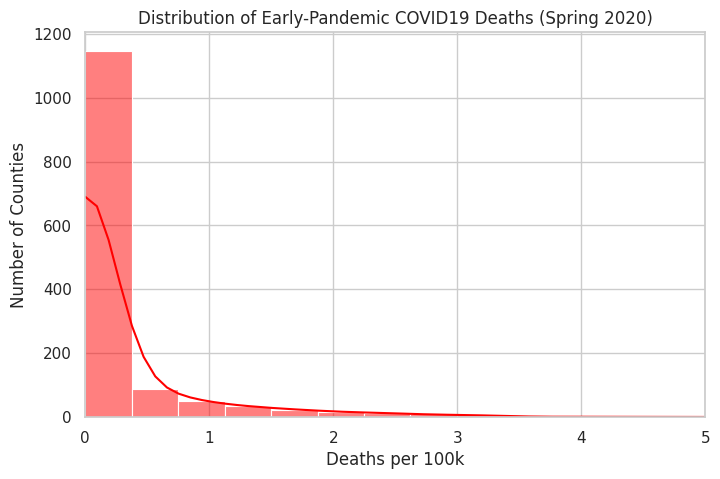

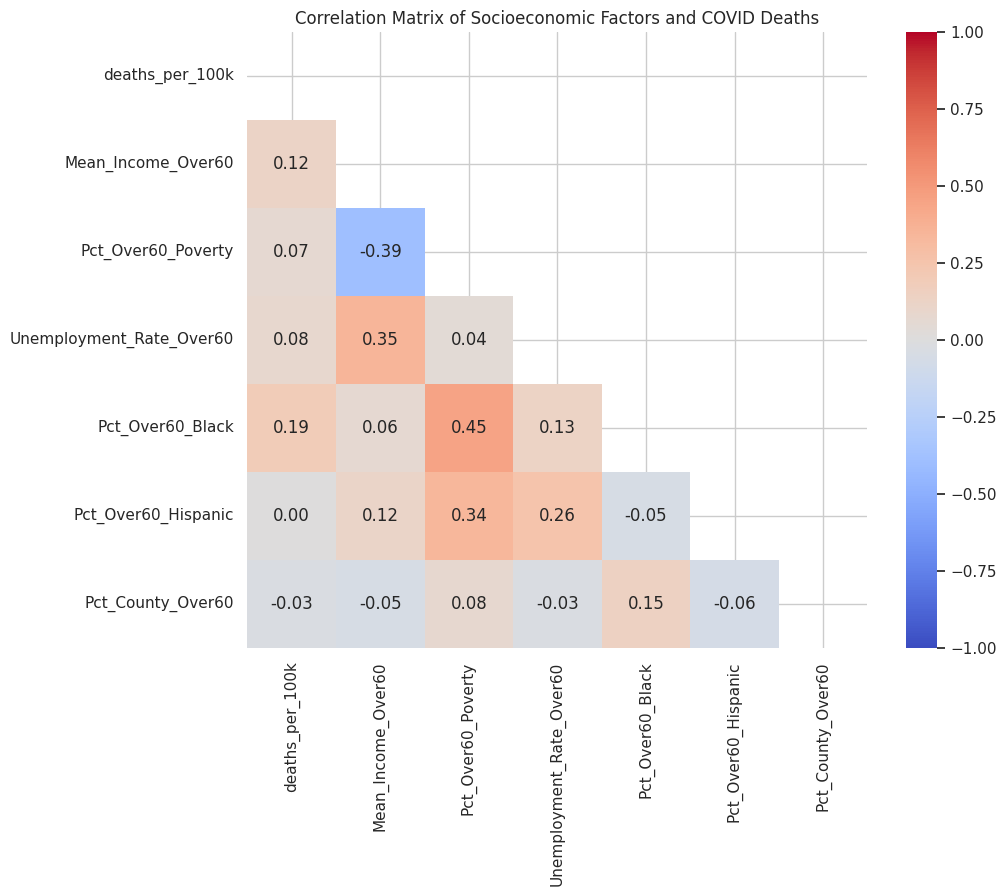

In [6]:
# Define feature list
features = [
    'Mean_Income_Over60', 
    'Pct_Over60_Poverty', 
    'Unemployment_Rate_Over60', 
    'Pct_Over60_Black', 
    'Pct_Over60_Hispanic', 
    'Pct_County_Over60'
]

# Plot the target distribution
plt.figure(figsize=(8, 5))
sns.histplot(final_df['deaths_per_100k'], bins=50, kde=True, color='red')
plt.title('Distribution of Early-Pandemic COVID19 Deaths (Spring 2020)')
plt.xlabel('Deaths per 100k')
plt.ylabel('Number of Counties')
plt.xlim(0,5)
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = final_df[['deaths_per_100k'] + features].corr()

# Create a mask to only show the bottom triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Socioeconomic Factors and COVID Deaths')
plt.show()

"Distribution of Early-Pandemic COVID Deaths"

- The histogram reveals a severe right skew in the target variable. Because the data is from the very early months of the pandemic, the majority of US counties had 0 or very few deaths. 


"Correlation of Socioeconomic Factors & COVID Deaths"

- This map shows a weak linear relationship between the chosen features and deaths per 100k.
- Counties with higher Black populations over 60 years old showed the strongest correlation. This aligns with other public health data showing that minority communities were disproportionately impacted early on in the pandemic.
- There are several examples of multicollinearity:
    - pct_over60_black & pct_over60_poverty (0.45), pct_over60_Hispanic and Poverty (0.34).
      - Highlights systemic socioeconomic overlaps
    - mean_income_over60 and pct_over60_poverty (-0.39)
      - Counties with higher mean senior incomes have lower
    - mean_income_over60 and unemployment_rate_over60 (0.35)
      - Could reflect the labor market for seniors in high-cost-of-living areas
     
Because of the large overlap in features and weak linear relationships, a Random Forest model will perform better than OLS. It will capture more complex, non-linear relationships without the bias from highly correlated features. 

# Model Creation & Evaluation

In [8]:
# Define features & target, Splitting data into test & training sets

X = final_df[clean_features]
y = final_df['deaths_per_100k']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data set shape (X): {X_train.shape}")
print(f"Testing data set shape (X): {X_test.shape}")

Training data set shape (X): (1121, 6)
Testing data set shape (X): (281, 6)


In [9]:
# Initialize & train the model

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train model
rf_model.fit(X_train, y_train)

# Predictions of trained model
y_pred = rf_model.predict(X_test)

In [10]:
# Calculate metrics, RMSE

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

print("Random Forest Performance")
print(f"R-squared: {r2:0.4f}")
print(f"RMSE: {rmse:.4f} deaths per 100k")

Random Forest Performance
R-squared: 0.0221
RMSE: 1.2212 deaths per 100k


Results show R2 of 0.0221, and RMSE 1.2212 deaths per 100k. These are relatively low as the data comes from the very beginning of the pandemic. 

# Feature Importance Analysis 

/tmp/ipykernel_55/657054061.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


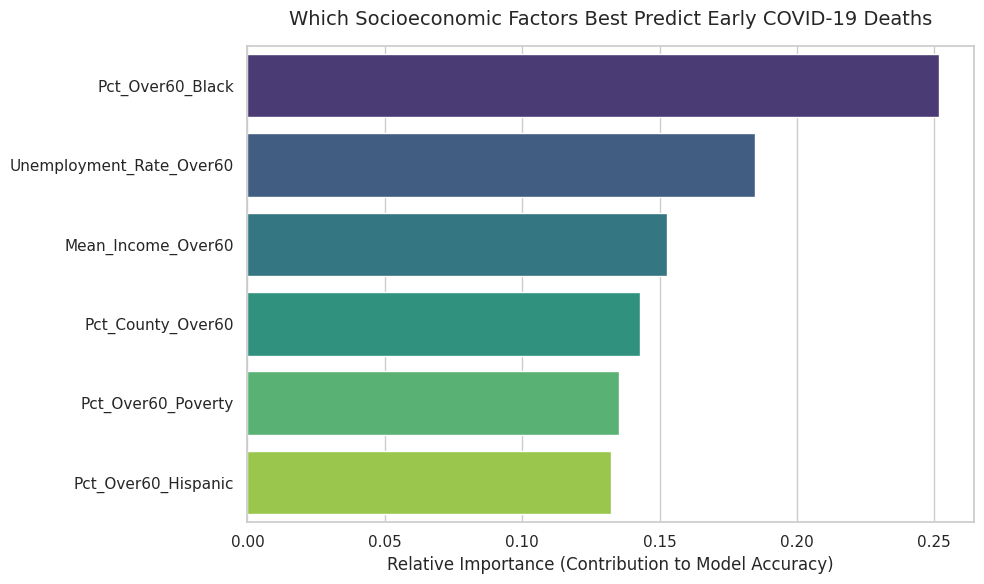

In [14]:
# Create dataframe to pair feature wtih importance score, sorting from most to least

importances = rf_model.feature_importances_
importance_df = pd.DataFrame({'Feature': clean_features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False) 

# Visualization of the result

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')

plt.title('Which Socioeconomic Factors Best Predict Early COVID-19 Deaths', fontsize=14, pad=15)
plt.xlabel('Relative Importance (Contribution to Model Accuracy)', fontsize=12)
plt.ylabel('')

plt.tight_layout()
plt.show()

# Conclusion

The goal of this analysis was to determine which socioeconomic factors were the strongest predictors of COVID-19 mortality in the over-60 population during the onset of the pandemic.

The Random Forest model identified the percentage of elderly Black residents (`Pct_Over60_Black`) as the most important socioeconomic predictor of early pandemic deaths. This was followed closely by senior unemployment rates and mean income. This data reinforces the public health consensus that existing systemic inequities and economic instability left these groups vulnerable. 

It is important to contextualize the model's performance metrics (R-squared: 0.0221). While this number is low, it would be expected given the nature of early-pandemic data (Spring 2020). During these early months, the virus was highly localized (i.e., major coastal travel hubs). The vast majority of US counties had recorded zero deaths, creating a massively skewed dataset. 

Because the virus was not yet widespread across the country, socioeconomic factors alone could not explain the total variance in death rates. However, the fact that `Pct_Over60_Black` emerged as the strongest signal through the noise of this skewed data is an important finding. It shows that where the virus did take hold early on, marginalized and economically disadvantaged senior populations had the most vulnerability. 

A valuable next step for this project would be to run this exact same model on data from late 2020 or early 2021. Once the virus had spread uniformly across all counties, we would likely see the R-squared value increase significantly, giving an even clearer picture of how socioeconomic status dictated pandemic outcomes.